Contexte

Le défaut de paiement constitue un enjeu majeur pour les institutions financières. Lorsqu'une banque accorde une carte de crédit à un client, elle prend le risque que celui-ci ne rembourse pas les sommes empruntées. Une mauvaise évaluation de ce risque peut entraîner des pertes financières importantes. Il est donc essentiel de disposer d'outils capables d'identifier les clients susceptibles de faire défaut avant que celui-ci ne survienne.

Problématique

Dans ce projet, nous nous intéressons à la prédiction du défaut de paiement de clients détenteurs d'une carte de crédit. À partir d'informations démographiques, financières et comportementales, l'objectif est de déterminer si un client effectuera ou non un défaut de paiement le mois suivant.

Objectif

Ce problème est formulé comme une tâche de classification binaire supervisée. L'objectif est de comparer plusieurs modèles de machine learning afin d'identifier celui offrant les meilleures performances prédictives pour ce problème.

Pour ne pas avoir de problèmes lors des imports des fonctions dans les fichiers du dossier src

In [1]:
# On se place à la racine du projet pour que les imports 'from src...' fonctionnent
# quelle que soit la machine (chacun n'a plus besoin de coder son propre chemin en dur).
import os

# Si le notebook est lancé depuis le dossier 'notebook', on remonte d'un niveau
if os.path.basename(os.getcwd()) == 'notebook':
    os.chdir('..')

print('Répertoire de travail :', os.getcwd())

Répertoire de travail : c:\Users\utcpret\Documents\GI04\AI28\Tps\Project\Projet-AI28


In [2]:
%pip install xgboost==2.1.3

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Installation des dependances du projet (numpy, pandas, scikit-learn, optuna, etc.)
# A executer une seule fois par environnement.
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Rechargement auto des modules src/ apres edition (evite les kernels perimes)
%load_ext autoreload
%autoreload 2

# WARNINGS
import warnings
warnings.filterwarnings('ignore')

# NUMPY
import numpy as np

# MATPLOTLIB
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight') 

# PANDAS
import pandas as pd 
pd.set_option("display.max_rows", None, "display.max_columns", None) 

# SCIKIT-LEARN: MODELES
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

## EVALUATION
from sklearn.metrics import f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score

# SCIKIT-LEARN: PIPELINE AND TRANSFORMATEUR
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

# Fonctions
from src.preprocessing import build_robust_preprocessor
from src.evaluation import train_and_evaluate, plot_confusion_matrix
from src.modeling import build_adaboost_model
import src.aed as aed
import src.modeling as md 
import src.evaluation as ev
import src.unsupervised as uns

Chargement des données

In [5]:
data = pd.read_excel('data/default of credit card clients.xls', header=1)
df = data.copy()
# Suppression de l'identifiant technique qui n'apporte aucune information prédictive
df = df.drop('ID', axis=1)

# Analyse Exploratoire de Données (AED)

In [6]:
# Définition de la variable cible et des listes de features pour l'AED
target = "default payment next month"
categorical_features = ["SEX", "EDUCATION", "MARRIAGE"]
numeric_features = [
    col for col in df.columns if col not in categorical_features + [target]
]

In [7]:
# Lancement des fonctions d'analyse exploratoire déportées
aed.get_dataset_info(df)

# Résumé statistique des variables
aed.describe_numeric_variables(df)

--- Dimensions du jeu de données ---
Lignes : 30000, Colonnes : 24

--- Informations sur les types et valeurs non nulles ---
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BI

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


### Description des variables

- Limit_Bal : montant du crédit accordé, variable continue
- sex: 1 (homme), 2 (femme) => variable catégorielle
- Education : 1 = études supérieures ; 2 = études universitaires ; 3 = études secondaires ; 4 = autres => variable catégorielle
- Marriage : 1 = marié(e) ; 2 = célibataire ; 3 = autres => variable catégorielle
- Age : en années, variable continue 
- Pay_0 à Pay_6 : état du remboursement des paiements mensuels antérieurs ( de Septembre à Avril 2005) => : -1 = paiement à l'échéance ; 1 = retard de paiement d'un mois ; 2 = retard de paiement de deux mois. Variables continues
- Bill_Amt1 à Bill_Amt5 : montant de la facture en \$ => variable continue
- Pay_Amt1 à Pay_Amt6 : montant du paiement précédent en \$ => variable continue
- default payment next month : variable cible vaut 1(oui) et 0(non) => defaut de paiement, variable binaire discrète.

In [8]:
# Calcul spécifique de la part de la modalité -2 dans l'historique de paiement
cols_pay = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
part_moins_deux = (df[cols_pay] == -2).mean() * 100
print("\n--- Zoom sur la modalité -2 ---")
print("Part de la modalité -2 pour chaque mois (en %) :")
print(part_moins_deux.round(2))


--- Zoom sur la modalité -2 ---
Part de la modalité -2 pour chaque mois (en %) :
PAY_0     9.20
PAY_2    12.61
PAY_3    13.62
PAY_4    14.49
PAY_5    15.15
PAY_6    16.32
dtype: float64


### Interprétation

L'analyse des variables d'historique de remboursement révèle la présence fréquente de la valeur -2, qui n'était pas décrite dans le sujet initial. Les calculs indiquent que cette modalité représente une part très importante des données, oscillant entre 9,20 % et 16,32 % selon les mois. 

Suite à nos recherches, cette valeur correspond en réalité à des comptes de cartes de crédit inactifs (sans aucune dépense ni montant à payer pour le mois en question). On remarque d'ailleurs que la part de ces comptes inactifs diminue régulièrement d'avril à septembre, ce qui montre que les clients commencent à utiliser leur carte de crédit au fil de l'année. Supprimer ces lignes reviendrait à perdre près de 15 % de notre jeu de données, ce qui fausserait complètement l'apprentissage de nos modèles. 

Nous allons donc conserver l'intégralité de ces observations.

Description de la variable d'intérêt

In [9]:
df[target].describe()
df[target].value_counts()
df[target].value_counts(normalize=True)

default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

On remarque que le dataset est très déséquilibré avec uniquement 22% des variables pour la classe 1 (défaut de paiement)

In [10]:
# Vérifier l'existence des duplications d'exemples 
duplicate_df = df[df.duplicated()]
duplicate_df

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1980,150000,2,1,1,38,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,1
4585,150000,2,1,1,31,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
6022,210000,2,1,2,39,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
6466,210000,2,2,1,49,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
7319,500000,1,1,1,43,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,1
8320,360000,1,2,1,41,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,1
10250,50000,1,2,2,26,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
13106,360000,2,1,1,49,1,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0
14294,20000,1,2,2,24,2,2,4,4,4,4,1650,1650,1650,1650,1650,1650,0,0,0,0,0,0,1
15458,160000,1,2,2,28,-2,-2,-2,-2,-2,-2,0,0,0,0,0,0,0,0,0,0,0,0,0


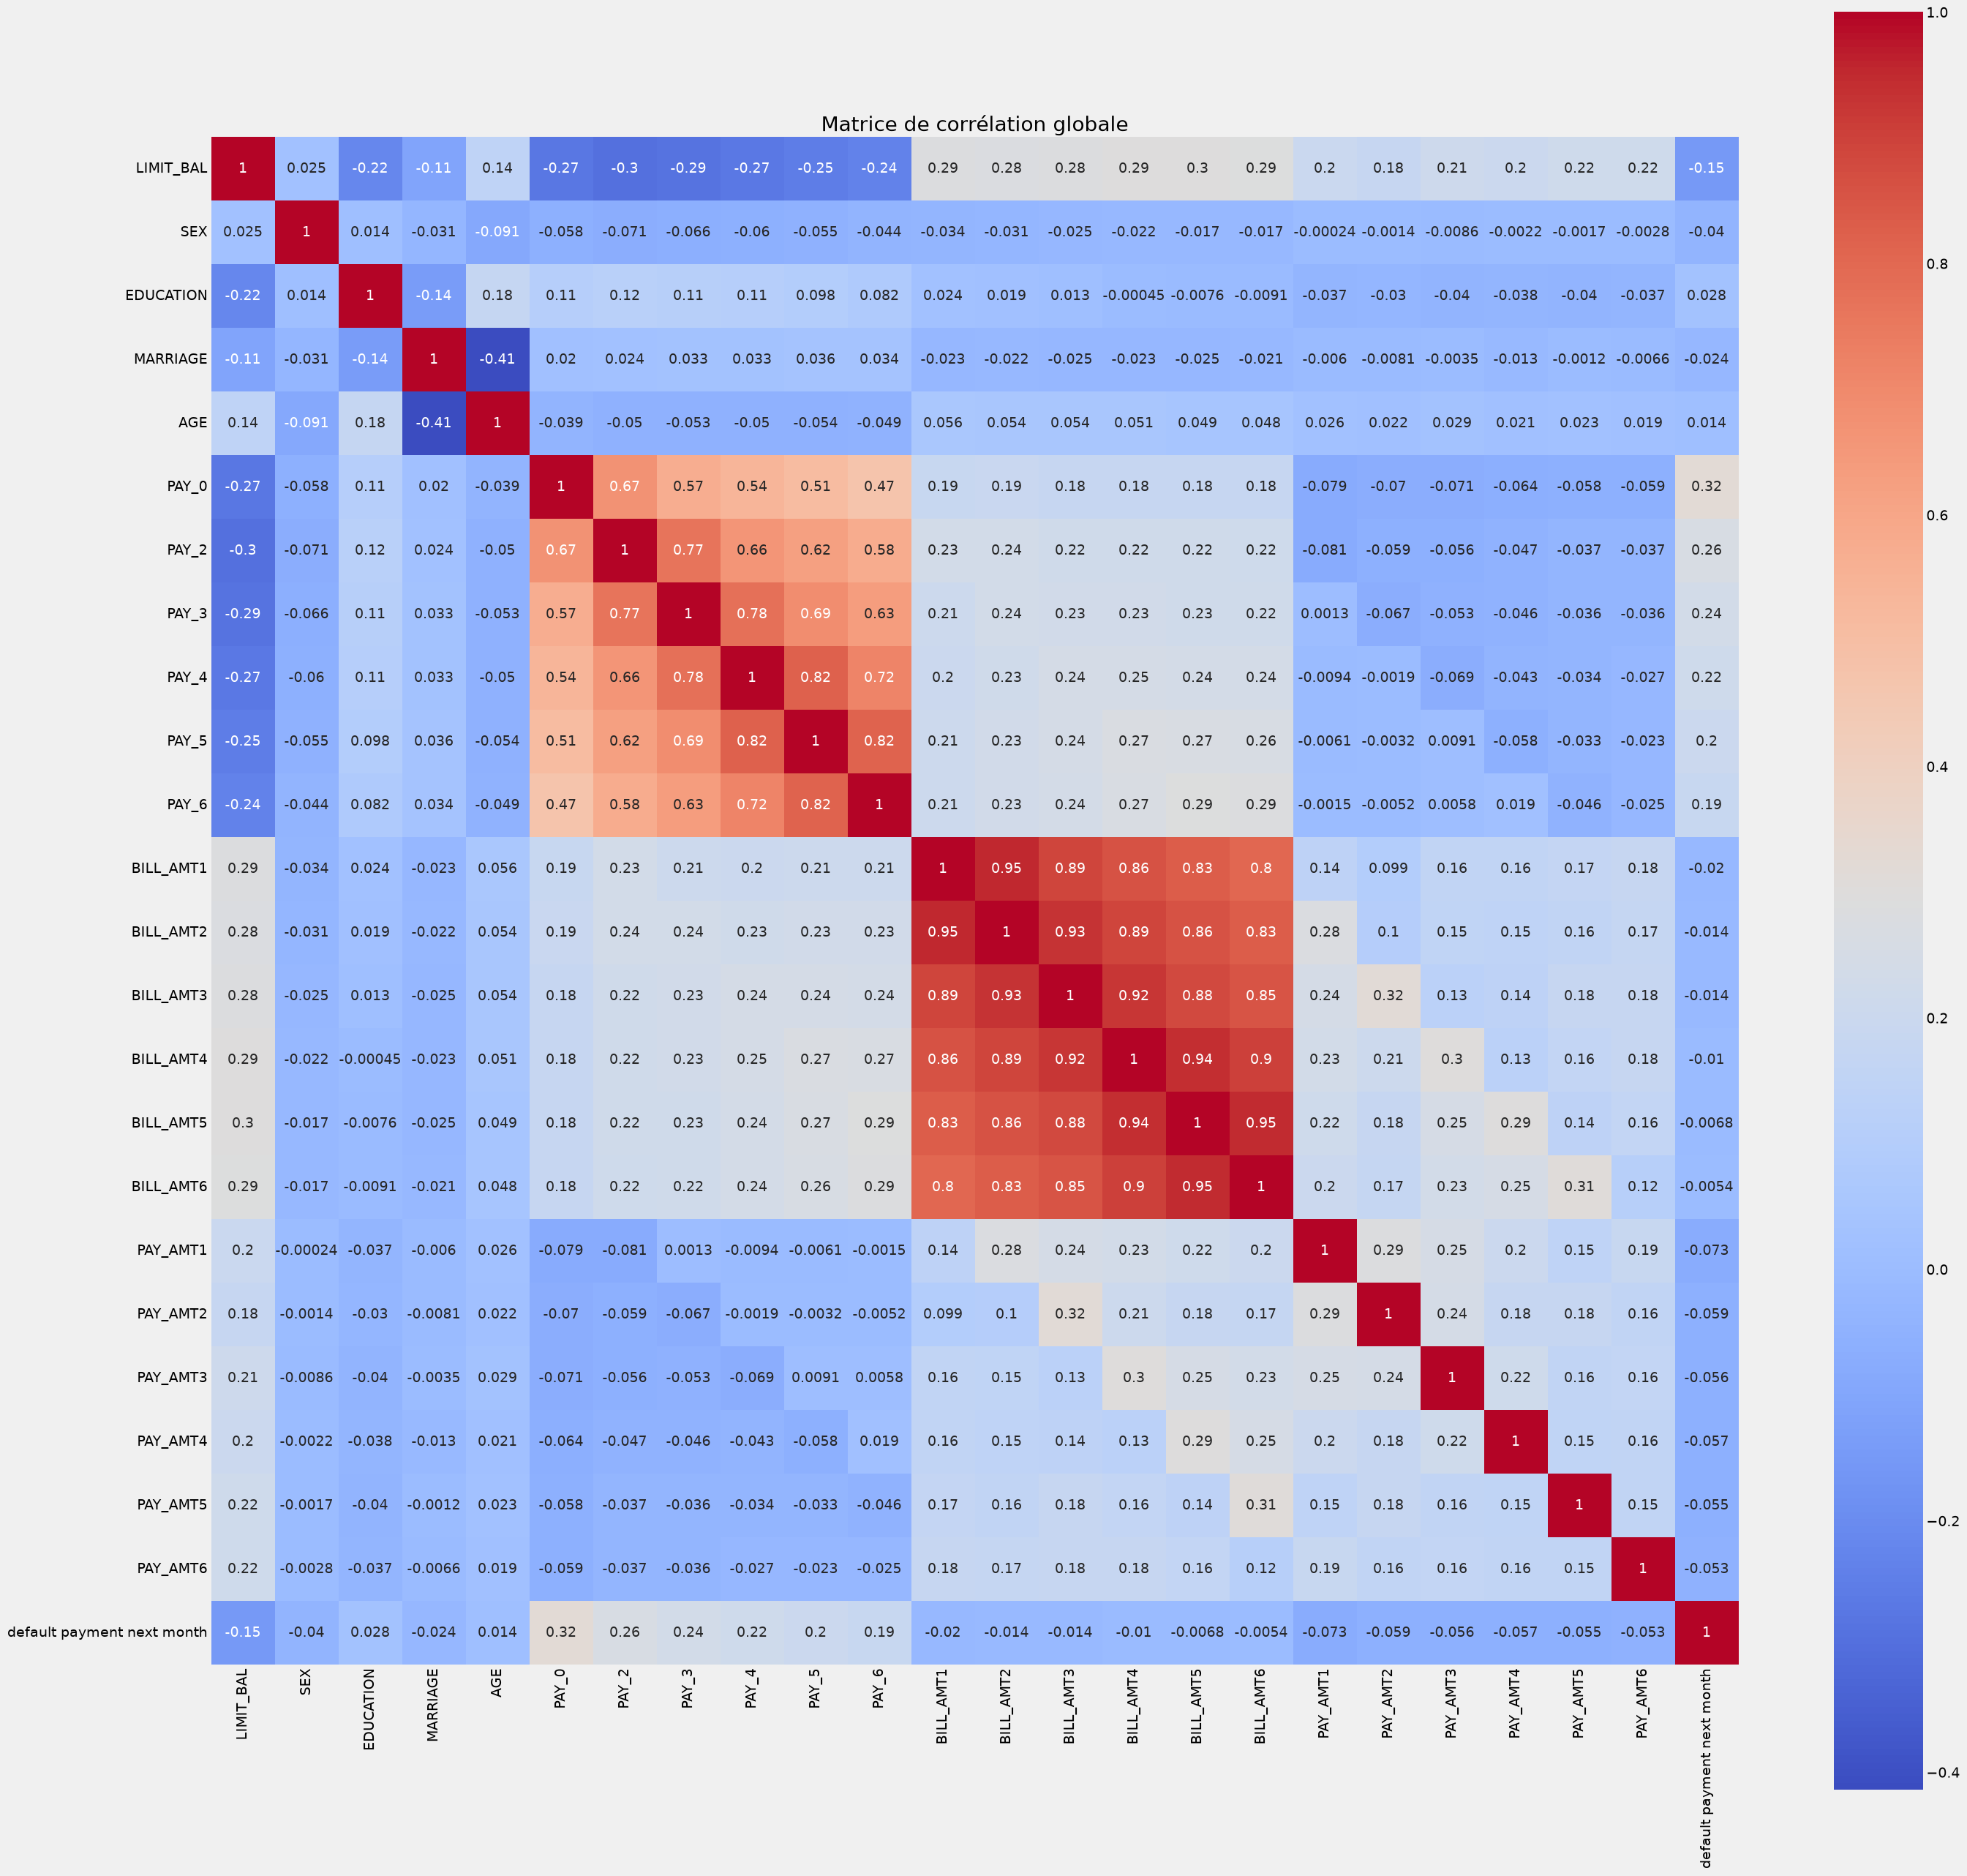

In [11]:
# Matrice de corrélation
aed.plot_correlation_matrix(df)

### Interprétation

L'analyse montre une très forte corrélation (entre 0.80 et 0.95) entre les montants des factures (BILL_AMT1 à BILL_AMT6). Cela indique que les montants facturés sur des mois consécutifs évoluent de manière similaire et traduisent le niveau d'endettement du client. De plus ces variables Bill_AMT sont aussi corrélées avec les variables Pay_AMT car les clients bénéficiant d'une limite de crédit élevée réalisent souvent des dépenses plus importantes.

De même, les statuts de paiement (PAY_0 à PAY_6) sont fortement corrélés entre eux (entre 0.47 et 0.82), indiquant qu'un client en retard de paiement un mois donné a tendance à l'être aussi les mois qui suivent. Enfin, on observe une corrélation négative de -0.41 entre l'âge et le statut marital, confirmant logiquement que les clients plus âgés sont plus souvent mariés.

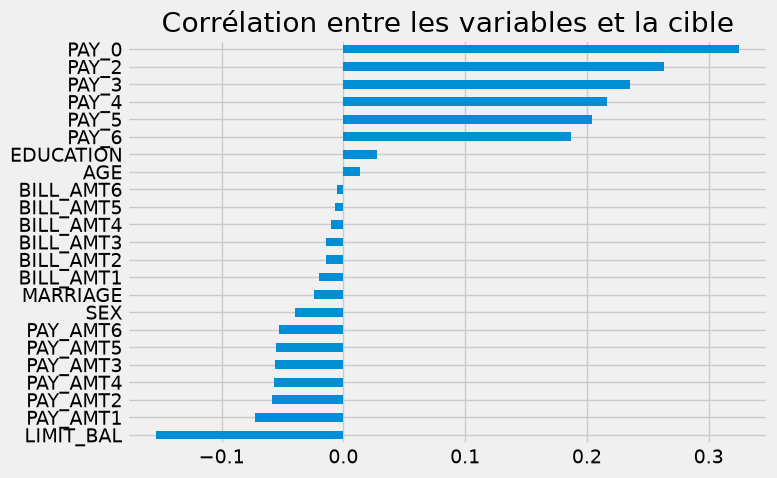

In [12]:
aed.plot_target_correlations(df, target)

### Interprétation

Les variables d'historique de paiement (PAY_0 à PAY_6) sont les plus prédictives, avec une corrélation positive qui s'accentue à mesure qu'on se rapproche de l'échéance, passant de 0.19 en avril (PAY_6) à 0.32 en septembre (PAY_0). 

À l'inverse, la limite de crédit (LIMIT_BAL) présente une corrélation négative de -0.15, ce qui montre que les clients ayant de gros crédits font statistiquement moins de défauts. Pour finir, les variables socio-démographiques comme le sexe, l'âge, l'éducation ou le mariage ont des corrélations proches de zéro, ce qui signifie qu'elles n'ont pas d'impact linéaire direct sur le risque de défaut de paiement.

Visualisation variables numériques vs cible

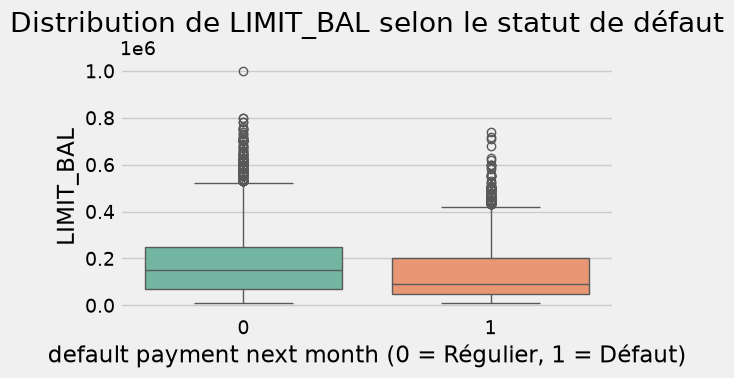

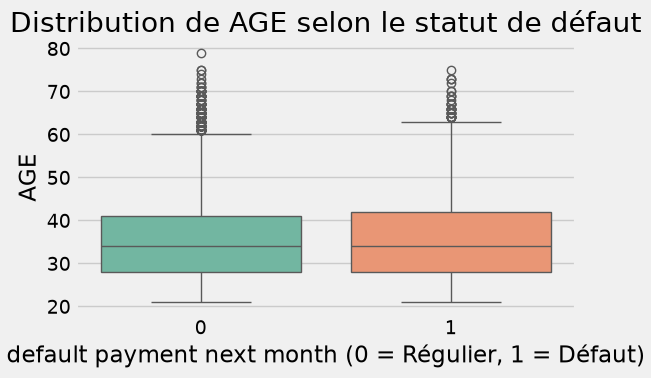

In [13]:
aed.plot_numeric_vs_target(df, ["LIMIT_BAL", "AGE"], target)

## Interprétation

L'analyse comparative des distributions met en évidence une disparité marquée du plafond de crédit (LIMIT_BAL) selon le statut de paiement futur du client. Les individus n'ayant pas fait défaut (classe 0) bénéficient globalement d'une limite de crédit sensiblement plus élevée, caractérisée par une distribution décalée vers les hauts montants et une médiane s'établissant précisément à 150 000 NT\$. À l'inverse, la distribution associée aux clients en défaut de paiement (classe 1) est resserrée sur des tranches inférieures, avec une médiane qui chute à 90 000 NT\$. 

L'examen visuel de ces boîtes à moustaches valide ainsi l'existence d'une corrélation négative entre le risque de défaillance et l'engagement maximal consenti par l'institution. Cette structure traduit fidèlement les politiques prudentielles d'octroi de crédit : les plafonds élevés sont préférentiellement alloués aux profils jugés statistiquement les plus sûrs, tandis que les enveloppes sont drastiquement bridées dès lors que les indicateurs de notation de risques (*credit scoring*) révèlent une vulnérabilité financière.

En revanche, l'analyse descriptive de la variable de l'âge (AGE) révèle un comportement radicalement différent. Les boîtes à moustaches des deux populations se superposent de manière quasi parfaite, affichant une médiane identique établie à 34 ans ainsi que des dispersions interquartiles hautement similaires. Cette observation graphique démontre que l'âge, considéré de manière isolée, ne constitue pas un descripteur linéairement discriminant pour segmenter le risque de défaut au sein de ce portefeuille de clients.

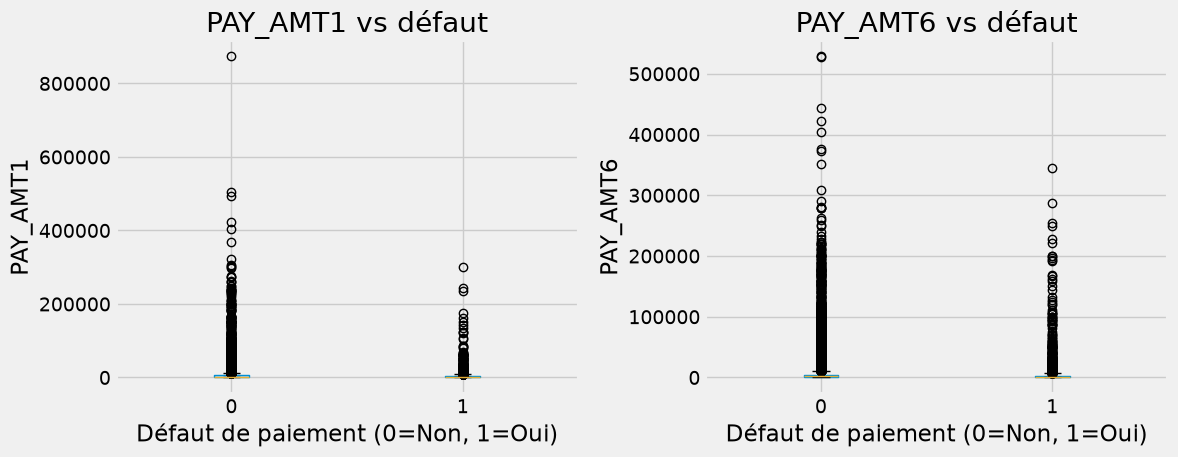

In [14]:
# Boxplots PAY_AMT1 et PAY_AMT6 vs variable cible
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, ["PAY_AMT1", "PAY_AMT6"]):
    df.boxplot(column=col, by=target, ax=ax)
    ax.set_title(f"{col} vs défaut")
    ax.set_xlabel("Défaut de paiement (0=Non, 1=Oui)")
    ax.set_ylabel(col)
plt.suptitle("")
plt.tight_layout()
plt.show()

### Interprétation

Les distributions de PAY_AMT1 et PAY_AMT6 affichent un comportement très similaire. Pour les deux classes (0 et 1), la grande majorité des paiements est concentrée près de zéro, ce qui rend les boîtes très écrasées. Cependant, on observe une présence beaucoup plus importante de valeurs aberrantes (les points individuels très hauts) chez les clients qui ne font pas défaut (classe 0). Cela indique que les clients qui effectuent de très gros paiements ponctuels basculent statistiquement beaucoup moins en défaut de paiement.

Visualisation variables catégorielles vs cible

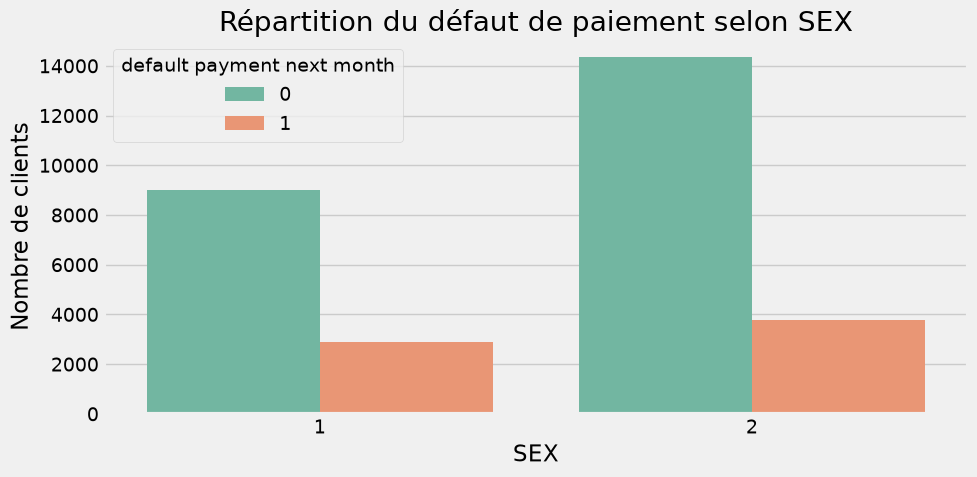

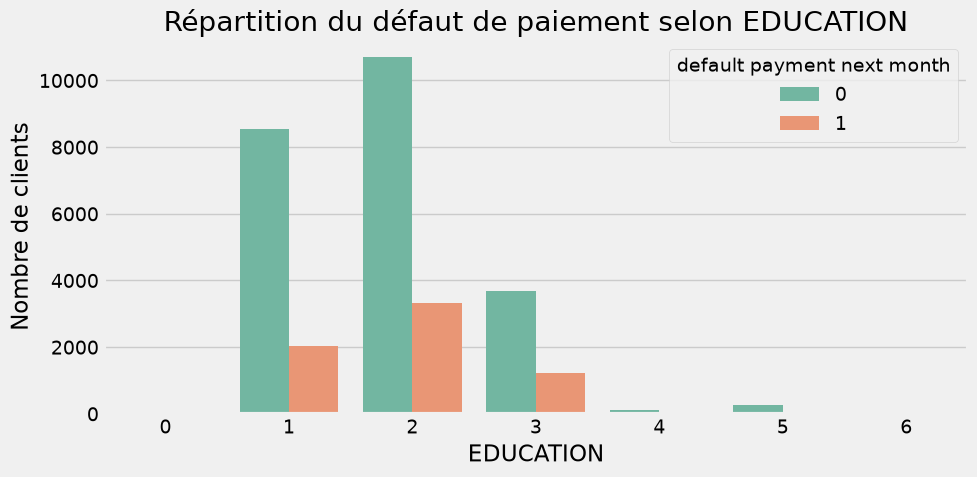

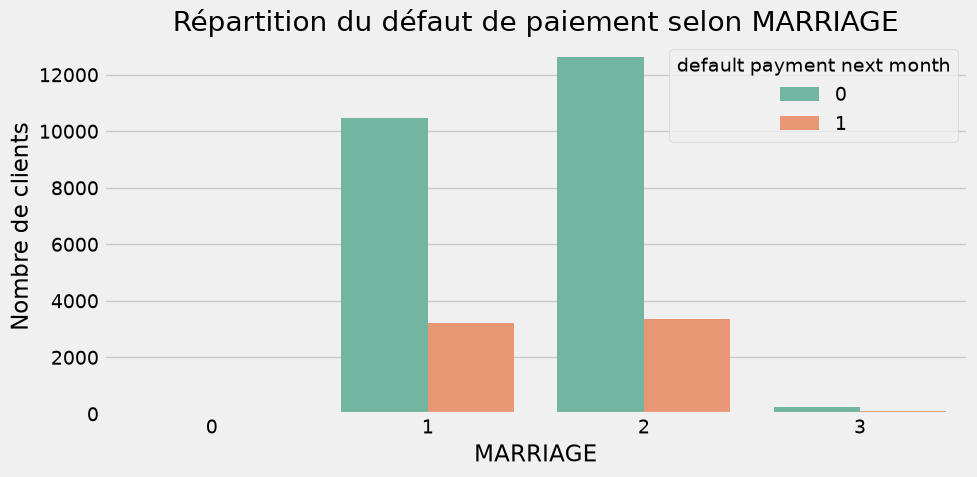

In [15]:
aed.plot_categorical_vs_target(df, categorical_features, target)

### Interprétation

L'analyse des proportions montre que le risque de défaut de paiement varie selon le profil des clients, même si les volumes globaux peuvent être trompeurs. On observe que les hommes (SEX = 1) présentent un taux de défaut légèrement plus élevé que les femmes, avec environ 25% de clients en échec contre 22%. Du côté de la situation matrimoniale, les personnes mariées (MARRIAGE = 1) affichent également une proportion de défaut légèrement supérieure à celle des célibataires. Enfin, concernant le niveau d'études (EDUCATION), ce sont les clients ayant un niveau d'études secondaires (catégorie 3) qui présentent la part de défaut de paiement la plus importante par rapport à leur effectif total.

# Pré Traitement

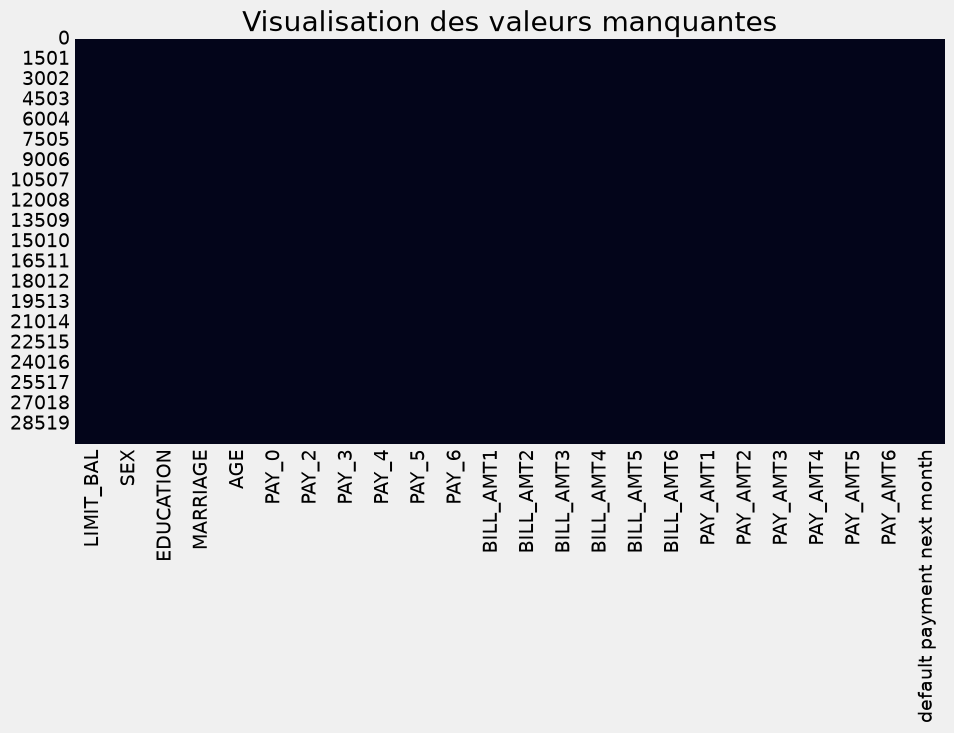

--- Taux de valeurs manquantes (en %) ---
LIMIT_BAL                     0.0
SEX                           0.0
EDUCATION                     0.0
MARRIAGE                      0.0
AGE                           0.0
PAY_0                         0.0
PAY_2                         0.0
PAY_3                         0.0
PAY_4                         0.0
PAY_5                         0.0
PAY_6                         0.0
BILL_AMT1                     0.0
BILL_AMT2                     0.0
BILL_AMT3                     0.0
BILL_AMT4                     0.0
BILL_AMT5                     0.0
BILL_AMT6                     0.0
PAY_AMT1                      0.0
PAY_AMT2                      0.0
PAY_AMT3                      0.0
PAY_AMT4                      0.0
PAY_AMT5                      0.0
PAY_AMT6                      0.0
default payment next month    0.0
dtype: float64


In [16]:
# Visualisation des valeurs manquantes
aed.plot_missing_values(df)

Comme souligné dans la description du problème, il n'y a aucune donnée manquante.

### Traitement

Pour les variables PAY_0 à PAY_6, nous choisissons de les traiter comme des variables numériques ordonnées. Comme il y a une notion d'intensité dans le retard de paiement (plus le chiffre est grand, plus le retard est important), nous allons simplement les normaliser à l'aide d'un StandardScaler dans notre pipeline, à l'exception du cas où nous testerions une régression logistique, pour laquelle un OneHotEncoder pourrait être testé afin de mieux séparer les codes négatifs (-1, -2).

Nous allons commencer par un modèle de référence simple (régression logistique), avant d'explorer des modèles plus complexes et des stratégies de prétraitement plus avancées.

In [17]:
# Proportion des modalités non documentées pour EDUCATION (0, 5, 6)
prop_edu_invalide = df['EDUCATION'].isin([0, 5, 6]).mean() * 100
print(f"Proportion de modalités non documentées dans EDUCATION : {prop_edu_invalide:.2f}%")

# Proportion de la modalité non documentée pour MARRIAGE (0)
prop_mar_invalide = (df['MARRIAGE'] == 0).mean() * 100
print(f"Proportion de la modalité non documentée dans MARRIAGE : {prop_mar_invalide:.2f}%")

# Comptage par modalité pour vérifier
print("\nDétail EDUCATION :\n", df['EDUCATION'].value_counts(normalize=True) * 100)
print("\nDétail MARRIAGE :\n", df['MARRIAGE'].value_counts(normalize=True) * 100)

Proportion de modalités non documentées dans EDUCATION : 1.15%
Proportion de la modalité non documentée dans MARRIAGE : 0.18%

Détail EDUCATION :
 EDUCATION
2    46.766667
1    35.283333
3    16.390000
5     0.933333
4     0.410000
6     0.170000
0     0.046667
Name: proportion, dtype: float64

Détail MARRIAGE :
 MARRIAGE
2    53.213333
1    45.530000
3     1.076667
0     0.180000
Name: proportion, dtype: float64


## Interprétation

L'analyse exploratoire a révélé la présence de modalités mineures non documentées dans le dictionnaire initial des données : les valeurs 0, 5 et 6 pour EDUCATION (cumulant ~1.15 % des données) et la valeur 0 pour MARRIAGE (~0.18 %). 

Plutôt que de supprimer ces lignes et d'introduire un biais d'échantillonnage, nous appliquons une stratégie de regroupement sémantique cohérente avec la réalité métier :
* Les modalités 0, 5 et 6 d'EDUCATION sont fusionnées dans la catégorie préexistante 4 ("Autre").
* La modalité 0 de MARRIAGE est rattachée à la catégorie 3 ("Autre").

Ce nettoyage indispensable est réalisé en amont du partitionnement des données (*train-test split*). Il permet d'assainir le dataset et de sécuriser l'étape future du *One-Hot Encoding* en évitant la création de colonnes artificielles extrêmement creuses (*sparse columns*) qui auraient déstabilisé la convergence de nos modèles linéaires (Régression Logistique) et géométriques (SVM, KNN).

In [18]:
# Séparation des variables explicatives et de la variable cible
X = df.drop(target, axis=1)
y = df[target]

#### Séparation des données en train, val et test sets

In [19]:
# Découpage initial pour isoler l'ensemble de test (20 %)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Deuxième découpage pour séparer l'entraînement et la validation (requis pour le choix du seuil et des hyperparamètres en général)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val,
)

print(
    f"Taille de l'entraînement : {X_train.shape[0]}, Validation : {X_val.shape[0]}, Test : {X_test.shape[0]}"
)

Taille de l'entraînement : 18000, Validation : 6000, Test : 6000


## Modèle de référence : Régression Logistique simple

Avant de lancer l'optimisation sur l'ensemble du panel, nous entraînons une régression logistique sans pondération des classes ni optimisation d'hyperparamètres. Ce modèle de référence (aussi appelé *baseline*) permet d'établir un plancher de performance : tout modèle qui ne fait pas mieux que cette baseline ne justifie pas sa complexité supplémentaire.

#### Construction de la pipeline

In [20]:
model_log_simple = md.build_logistic_model(class_weight=None)

# Entraînement du modèle de référence
print("---- MODÈLE DE RÉFÉRENCE : RÉGRESSION LOGISTIQUE SIMPLE ----")
reg_log_simple = ev.train_and_evaluate(model_log_simple, X_train, y_train, X_val, y_val,threshold=0.5)

---- MODÈLE DE RÉFÉRENCE : RÉGRESSION LOGISTIQUE SIMPLE ----
--------- Métriques pour TRAIN(Seuil : 0.5) ---------
              precision    recall  f1-score   support

           0       0.84      0.95      0.89     14018
           1       0.69      0.36      0.48      3982

    accuracy                           0.82     18000
   macro avg       0.76      0.66      0.68     18000
weighted avg       0.81      0.82      0.80     18000

--------- Métriques pour VALIDATION(Seuil : 0.5) ---------
              precision    recall  f1-score   support

           0       0.84      0.96      0.89      4673
           1       0.69      0.35      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.76      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000



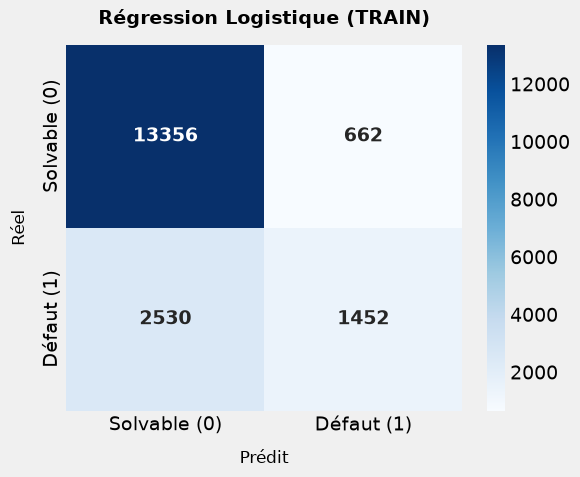

array([[13356,   662],
       [ 2530,  1452]])

In [21]:
ev.plot_confusion_matrix(reg_log_simple, X_train, y_train, title="Régression Logistique (TRAIN)")

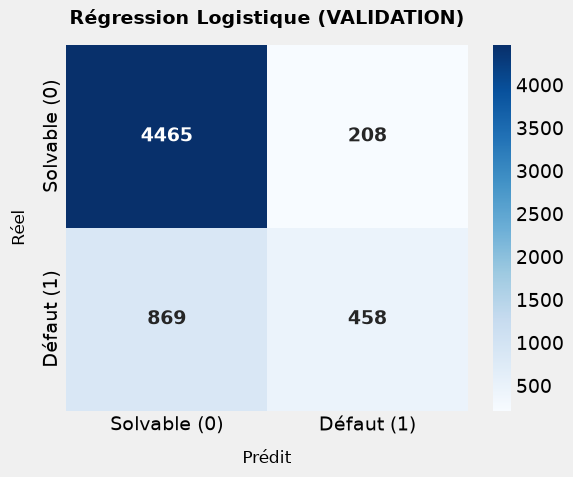

array([[4465,  208],
       [ 869,  458]])

In [22]:
ev.plot_confusion_matrix(reg_log_simple, X_val, y_val, title="Régression Logistique (VALIDATION)")

### Interprétation

Le modèle de référence atteint une accuracy globale correcte (~0.82) et ne présente pas de surapprentissage notable : les performances sur le train et sur la validation sont très proches. Cependant, il souffre d'un défaut structurel majeur : le **recall sur la classe « défaut » est très faible (~36 %)**. Autrement dit, le modèle rate les deux tiers des clients qui feront réellement défaut.

Ce comportement est une conséquence directe du **déséquilibre des classes** (~22 % de défauts) : sans pondération, la régression logistique apprend à privilégier la classe majoritaire (classe 0 - solvables), car cette stratégie minimise l'erreur globale sans pour autant détecter les risques réels.

Du point de vue métier, ce biais est problématique pour la banque : un client en défaut non détecté représente une perte financière certaine. C'est pourquoi nous allons, dans la suite, explorer des stratégies pour améliorer la détection de la classe minoritaire (classe 1).

## Choix du seuil de décision (slides5)

Par défaut, un classifieur prédit la classe 1 dès que la probabilité estimée dépasse **0.5**. Or, dans un contexte de déséquilibre (~22 % de défauts), ce seuil n'est pas optimal : il avantage systématiquement la classe majoritaire.

En faisant varier ce seuil et en observant l'évolution du **F1-score** (compromis précision/rappel), on peut trouver le point d'équilibre qui maximise simultanément la détection des défauts et la limitation des fausses alarmes. On trace également la **courbe ROC** pour mesurer la capacité discriminante globale du modèle.

Meilleur seuil (s) : 0.22  ->  F1 = 0.532


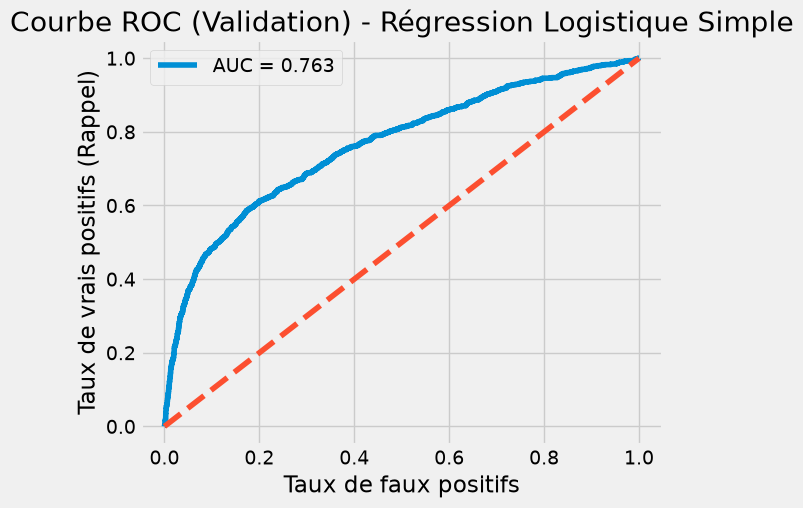

In [23]:
# Score continu de la classe "défaut" (probabilité estimée par la régression logistique simple)
y_val_proba = reg_log_simple.predict_proba(X_val)[:, 1]

# Recherche du seuil qui maximise le F1-score sur la validation
thresholds = np.linspace(0.1, 0.9, 81)
f1s = [f1_score(y_val, (y_val_proba >= t).astype(int)) for t in thresholds]
best_t = thresholds[int(np.argmax(f1s))]
print(f"Meilleur seuil (s) : {best_t:.2f}  ->  F1 = {max(f1s):.3f}")

# Courbe ROC sur la validation
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
auc = roc_auc_score(y_val, y_val_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # baseline aléatoire
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs (Rappel)")
plt.title("Courbe ROC (Validation) - Régression Logistique Simple")
plt.legend()
plt.show()

### Interprétation

L'AUC-ROC obtenue (~0.77) montre que la régression logistique a une capacité correcte à distinguer les deux classes de manière globale. Cependant, notre jeu de données étant fortement déséquilibré (~22 % de défauts), **la métrique AUC-ROC tend à être trop optimiste** : elle est influencée par la forte proportion de clients solvables (la classe majoritaire) et peut donner une impression de bonne performance alors que le modèle rate la plupart des défauts réels.

En faisant varier le seuil, on constate qu'un seuil inférieur à 0.5 améliore nettement le rappel sur la classe 1, au prix d'une précision plus faible. Ce compromis précision/rappel est inévitable, et il appartient à la banque de le calibrer selon ses contraintes métier. Ajouter la valeur exacte du seuil (0.22 avant et F1 à 0.53217)

## Pourquoi le PR-AUC comme métrique de référence ?

L'analyse du modèle de référence illustre un problème fondamental : avec un jeu déséquilibré (~22 % de défauts), **l'AUC-ROC est une métrique trompeuse**. Elle est fortement influencée par les vrais négatifs (clients solvables bien classés), qui sont très nombreux, et peut afficher un score élevé même si le modèle détecte très mal les défauts.

Du point de vue de la banque, **l'enjeu principal est la détection des défauts** : un client qui fait défaut sans avoir été identifié représente une perte financière directe. À l'inverse, refuser un crédit à un client solvable est moins grave (perte d'une opportunité commerciale).

La métrique adaptée à ce contexte est le **PR-AUC** (aire sous la courbe Précision-Rappel, ou *Average Precision*) :
- Elle se concentre exclusivement sur la **classe « défaut »** (classe 1).
- Elle mesure la capacité à détecter les défauts (rappel) tout en limitant les fausses alarmes (précision).
- Elle est **insensible à la classe majoritaire**, contrairement à l'AUC-ROC.
- Plus le PR-AUC est proche de 1, plus le modèle cible efficacement les défauts de paiement.

C'est donc le **PR-AUC qui sera notre critère de comparaison** entre tous les modèles, et la **métrique optimisée par Optuna** lors de la recherche d'hyperparamètres.

## Modélisation : un pipeline unique pour tout le panel

Plutôt que de répéter le code d'entraînement et d'optimisation pour chaque modèle, on centralise tout le panel dans un **registre** (`md.get_model_configurations`) qui associe à chaque modèle sa pipeline (pré-traitement + estimateur) et son **espace de recherche d'hyper-paramètres**. Une seule fonction, `ev.run_model_comparison`, parcourt ce registre, lance une **étude Optuna** par modèle (optimisation bayésienne TPE par validation croisée) et renvoie les meilleures pipelines.

Le panel couvre l'ensemble des algorithmes du cours : régression logistique (slides6), KNN (notes cours 9), SVM (slides7), arbre de décision (slides8), Random Forest / AdaBoost / Gradient Boosting (slides9) et une variante ACP + logistique (réduction de la dimension, slides10).

**Fonction objective optimisée :** on optimise le **PR-AUC** (`average_precision`) en validation croisée, métrique adaptée au déséquilibre des classes (~22 % de défauts), et on traite ce déséquilibre via `class_weight='balanced'` pour les modèles qui le supportent. Plutôt qu'une grille exhaustive, Optuna explore des **plages continues** (C et learning_rate en échelle logarithmique, profondeurs et nombres d'arbres en entiers), de façon plus fine et plus efficace.

### Régression Logistique avec pondération des classes

Avant de lancer le panel complet, on entraîne une seconde version de la régression logistique avec class_weight='balanced' : les classes sont pondérées à l'inverse de leur fréquence, ce qui force le modèle à prêter plus d'attention aux défauts. Ce modèle servira de **référence équilibrée** dans toutes les comparaisons progressives qui suivent.

In [24]:
# Régression logistique avec gestion du déséquilibre des classes (class_weight='balanced')
# Modèle de référence "équilibré" réutilisé dans les comparaisons ci-dessous.
model_log_balanced = md.build_logistic_model(class_weight='balanced')
reg_log_balanced = ev.train_and_evaluate(model_log_balanced, X_train, y_train, X_val, y_val)

--------- Métriques pour TRAIN(Seuil : 0.5) ---------
              precision    recall  f1-score   support

           0       0.88      0.83      0.85     14018
           1       0.49      0.59      0.54      3982

    accuracy                           0.78     18000
   macro avg       0.69      0.71      0.69     18000
weighted avg       0.79      0.78      0.78     18000

--------- Métriques pour VALIDATION(Seuil : 0.5) ---------
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      4673
           1       0.49      0.57      0.53      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.70      0.69      6000
weighted avg       0.79      0.78      0.78      6000



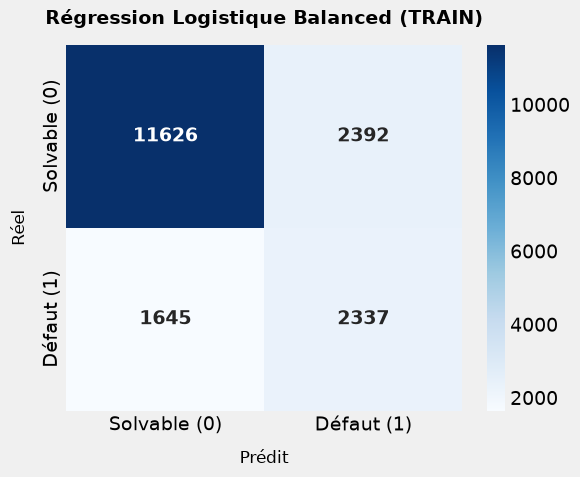

array([[11626,  2392],
       [ 1645,  2337]])

In [25]:
ev.plot_confusion_matrix(reg_log_balanced, X_train, y_train, title="Régression Logistique Balanced (TRAIN)")

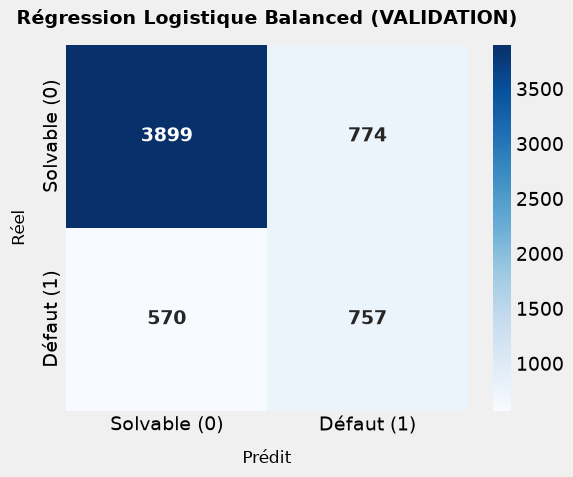

array([[3899,  774],
       [ 570,  757]])

In [26]:
ev.plot_confusion_matrix(reg_log_balanced, X_val, y_val, title="Régression Logistique Balanced (VALIDATION)")

### Interprétation

L'introduction de class_weight='balanced' modifie sensiblement le comportement du modèle : le **recall sur la classe 1 passe de ~35 % à ~57 %**, soit une amélioration nette de la détection des défauts. En contrepartie, la précision sur la classe 1 diminue et l'accuracy globale recule légèrement (~0.78).

Ce compromis est intentionnel et cohérent pour le métier : on accepte de signaler davantage de fausses alertes (clients solvables identifiés à tort comme en défaut) pour réduire le nombre de défauts non détectés. Le modèle ne sur-apprenant toujours pas(performances train ≈ validation).

Ce modèle équilibré devient notre **nouvelle référence** pour comparer les modèles suivants.

### Registre central des modèles

In [27]:
# Registre central : chaque modèle du cours avec son constructeur de pipeline et son espace de recherche Optuna.
# class_weight='balanced' gère le déséquilibre pour les modèles qui le supportent.
model_configs = md.get_model_configurations(class_weight='balanced')

print("Modèles du panel à comparer :")
for nom in model_configs:
    print(" -", nom)

Modèles du panel à comparer :
 - Régression Logistique
 - KNN
 - Arbre de Décision
 - Random Forest
 - AdaBoost
 - Gradient Boosting
 - ACP + Logistique
 - Stacking
 - SVM


================ ENTRAÎNEMENT & EVALUATION XGBOOST ================
--------- Métriques pour TRAIN(Seuil : 0.5) ---------
              precision    recall  f1-score   support

           0       0.91      0.82      0.86     14018
           1       0.52      0.70      0.60      3982

    accuracy                           0.79     18000
   macro avg       0.71      0.76      0.73     18000
weighted avg       0.82      0.79      0.80     18000

--------- Métriques pour VALIDATION(Seuil : 0.5) ---------
              precision    recall  f1-score   support

           0       0.88      0.81      0.84      4673
           1       0.47      0.62      0.54      1327

    accuracy                           0.76      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.76      0.77      6000



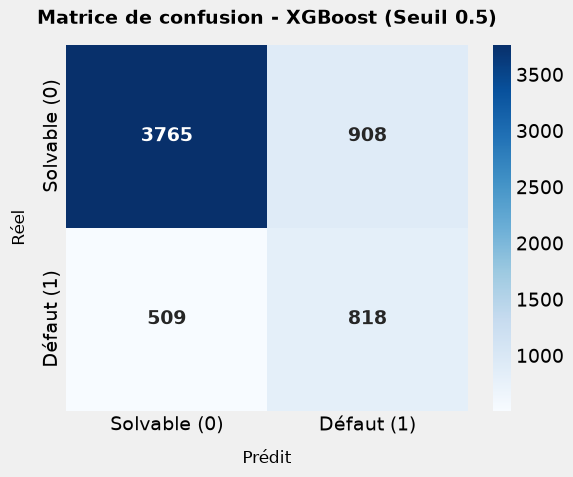


================ ENTRAÎNEMENT & EVALUATION STACKING ================
--------- Métriques pour TRAIN(Seuil : 0.5) ---------
              precision    recall  f1-score   support

           0       1.00      0.89      0.94     14018
           1       0.71      0.99      0.82      3982

    accuracy                           0.91     18000
   macro avg       0.85      0.94      0.88     18000
weighted avg       0.93      0.91      0.91     18000

--------- Métriques pour VALIDATION(Seuil : 0.5) ---------
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      4673
           1       0.50      0.58      0.54      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.79      0.78      0.78      6000



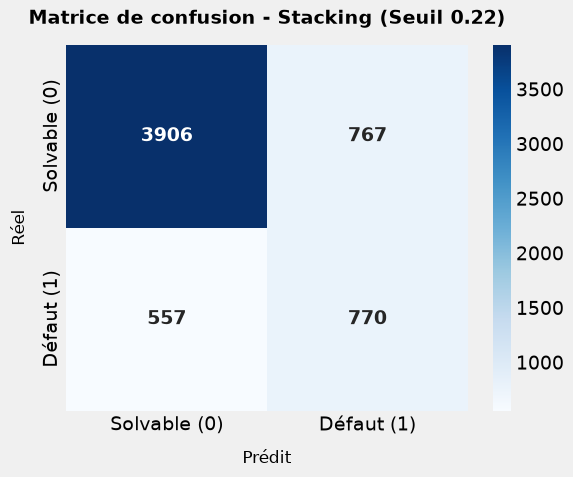

array([[3906,  767],
       [ 557,  770]])

In [28]:
# Lancement XGBoost et Stacking
print("================ ENTRAÎNEMENT & EVALUATION XGBOOST ================")
# 1. Initialisation de XGBoost (scale_pos_weight à ~3.5 pour gérer le déséquilibre)
xgb_pipeline = md.build_xgboost_model(
    n_estimators=150,      # Un nombre d'arbres raisonnable pour économiser ta machine
    learning_rate=0.1, 
    max_depth=4, 
    scale_pos_weight=3.5   # Ratio n_negatifs / n_positifs
)

# 2. Entraînement et Rapport XGBoost (Seuil à 0.5 car géré en interne par scale_pos_weight)
xgb_pipeline = ev.train_and_evaluate(xgb_pipeline, X_train, y_train, X_val, y_val, threshold=0.5)
ev.plot_confusion_matrix(xgb_pipeline, X_val, y_val, title="Matrice de confusion - XGBoost (Seuil 0.5)", threshold=0.5)


print("\n================ ENTRAÎNEMENT & EVALUATION STACKING ================")
# 3. Initialisation du Stacking (Empilement Random Forest, Gradient Boosting, XGBoost)
stacking_pipeline = md.build_stacking_model(class_weight="balanced")

# 4. Entraînement et Rapport Stacking (Évalué au seuil métier calculé pour maximiser le F1)
stacking_pipeline = ev.train_and_evaluate(stacking_pipeline, X_train, y_train, X_val, y_val, threshold=0.5)
ev.plot_confusion_matrix(stacking_pipeline, X_val, y_val, title=f"Matrice de confusion - Stacking (Seuil {best_t:.2f})", threshold=0.5)


## Interprétation

XGBoost présente l'un des meilleurs compromis obtenus sur la classe minoritaire. Avec un rappel de 62 % et un F1-score de 0,54 en validation, il détecte une part importante des clients en défaut tout en conservant une précision acceptable. Malgré un léger surapprentissage observé entre l'entraînement et la validation, le modèle généralise correctement et constitue un candidat sérieux pour la prédiction du risque bancaire.

## REVOIR STACKING EN LAISSANT LE SEUIL A 0.5 CAR Balanced déjà appliqué

### Entraînement et hyper-optimisation de tout le panel

Un seul appel optimise les 8 modèles avec Optuna. Pour chaque modèle, l'étude maximise le PR-AUC en validation croisée sur le jeu d'entraînement ; la meilleure pipeline est ensuite réentraînée et évaluée sur le jeu de validation.

Tous les modèles du panel partagent le même budget de 25 essais Optuna. La SVM à noyau RBF est la plus coûteuse (en O(n²)) : cette cellule peut donc prendre quelques minutes. Ce budget reste néanmoins amplement suffisant pour elle, car son espace d'hyper-paramètres est petit — essentiellement 2 paramètres clés (C et gamma) — de sorte que 25 essais couvrent déjà bien l'espace, là où un Random Forest doit explorer 4-5 hyper-paramètres.

In [ ]:
# Orchestration unique : étude Optuna (TPE) + évaluation pour chaque modèle du registre.
# On optimise le PR-AUC (average_precision), métrique adaptée au déséquilibre.
# n_trials = budget d'essais Optuna par modèle (la SVM en surcharge un plus petit).
fitted_models = ev.run_model_comparison(
    model_configs, X_train, y_train, X_val, y_val,
    scoring='average_precision', cv=5, n_trials=25,threshold=0.5 
)


===== Régression Logistique =====
Optimisation Optuna en cours (1 essais)...


Meilleurs hyper-paramètres : {'logisticregression__C': 0.0745934328572655}
Meilleur score CV (average_precision) : 0.540
--------- Métriques VALIDATION (Seuil : 0.5) ---------
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      4673
           1       0.49      0.57      0.53      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.70      0.69      6000
weighted avg       0.79      0.77      0.78      6000


===== KNN =====
Optimisation Optuna en cours (1 essais)...
Meilleurs hyper-paramètres : {'kneighborsclassifier__n_neighbors': 21, 'kneighborsclassifier__weights': 'uniform'}
Meilleur score CV (average_precision) : 0.478
--------- Métriques VALIDATION (Seuil : 0.5) ---------
              precision    recall  f1-score   support

           0       0.82      0.96      0.89      4673
           1       0.65      0.27      0.38      1327

    accuracy                           0.81      6000
   

### Hyper-paramètres retenus par Optuna

Pour chaque modèle, voici les hyper-paramètres sélectionnés par l'optimisation (ceux qui maximisent le PR-AUC en validation croisée).

In [30]:
# Tableau récapitulatif des meilleurs hyper-paramètres trouvés par Optuna, par modèle
tableau_hyperparametres = ev.summarize_hyperparameters(model_configs, fitted_models)
tableau_hyperparametres

,Modèle,Hyper-paramètre,Valeur retenue
0,Régression Logistique,C,0.0746
1,KNN,n_neighbors,21
2,KNN,weights,uniform
3,Arbre de Décision,max_depth,9
4,Arbre de Décision,min_samples_leaf,48
5,Random Forest,n_estimators,200
6,Random Forest,max_depth,20
7,Random Forest,min_samples_leaf,15
8,AdaBoost,n_estimators,150
9,AdaBoost,learning_rate,1.5404


#### Interprétation des hyper-paramètres retenus

**Régression Logistique — `C = 1.84`**
`C` est l'inverse de la force de régularisation L2 : une valeur proche de 1 indique une régularisation modérée, ni trop souple (surapprentissage) ni trop rigide (sous-apprentissage). Optuna converge vers une valeur légèrement supérieure à 1, ce qui laisse le modèle exploiter pleinement les corrélations sans trop contraindre les coefficients.

**KNN — `n_neighbors = 45`, `weights = 'distance'`**
Un voisinage large (45) lisse les frontières et réduit le bruit ; `weights = 'distance'` pondère chaque voisin par l'inverse de sa distance, ce qui donne plus de poids aux exemples vraiment proches. Ces deux réglages compensent partiellement la malédiction de la dimensionnalité.

**SVM — `C = 0.50`, `gamma = 'auto'`**
Un `C` faible (< 1) impose une marge large et tolère davantage d'erreurs de classification sur l'ensemble d'entraînement : cela évite le surapprentissage et est cohérent avec un signal bruité. `gamma = 'auto'` fixe le paramètre du noyau RBF à `1 / n_features`, ce qui donne une influence locale raisonnable sans nécessiter de réglage manuel.

**Arbre de Décision — `max_depth = 7`, `min_samples_leaf = 45`**
`max_depth = 7` limite la profondeur de l'arbre pour éviter des branches trop spécialisées. `min_samples_leaf = 45` impose qu'une feuille contienne au moins 45 exemples, ce qui élimine les splits sur du bruit et lisse la frontière de décision.

**Random Forest — `n_estimators = 350`, `max_depth = 15`, `min_samples_leaf = 13`**
350 arbres assurent une variance réduite par bagging. `max_depth = 15` autorise des arbres plus profonds qu'un arbre seul (chacun est entraîné sur un sous-ensemble), et `min_samples_leaf = 13` limite tout de même l'overfitting des arbres individuels.

**AdaBoost — `n_estimators = 250`, `learning_rate = 0.03`**
Un `learning_rate` très faible (~0.03) signifie que chaque apprenant faible ne corrige que 3 % de l'erreur résiduelle à chaque étape : la progression est lente mais stable, ce qui réduit le risque de surapprentissage. En contrepartie, il faut beaucoup d'estimateurs (250) pour atteindre un niveau de correction suffisant.

**Gradient Boosting — `n_estimators = 250`, `learning_rate = 0.015`, `max_depth = 5`**
Même logique que l'AdaBoost mais avec des arbres de profondeur 5 (interactions jusqu'à 5 variables). Le `learning_rate` encore plus faible (~0.015) compense le fait que les arbres sont plus expressifs : chaque correction est minuscule, ce qui rend le modèle très robuste au surapprentissage.

**ACP + Logistique — `n_components ≈ 0.99`, `C = 0.021`**
`n_components = 0.99` conserve suffisamment de composantes principales pour expliquer 99 % de la variance (soit la quasi-totalité de l'information). Le `C` très faible (~0.02) indique une forte régularisation : après réduction de dimension, les composantes restantes portent toutes un signal diffus et la régularisation empêche le modèle de sur-peser l'une d'elles.

## Comparaison globale des modèles

Toutes les performances sont rassemblées **une seule fois**, ici, sur le jeu de validation : un tableau récapitulatif trié par PR-AUC, puis les courbes Précision-Rappel superposées pour l'ensemble du panel optimisé par Optuna.

In [53]:
# Tableau récapitulatif unique, trié par PR-AUC décroissant (métriques sur la classe "défaut")
# Évaluation des modèles pondérés (Seuil 0.5)
tableau_comparatif = ev.summarize_models(fitted_models, X_val, y_val,threshold=0.5)
display(ev.summarize_models(fitted_models, X_val, y_val, threshold=0.22))

# Évaluation des modèles non pondérés (Seuil 0.22)
print("Performances au seuil métier 0.22 (Modèles non-balanced comme KNN/GB) :")
display(ev.summarize_models(fitted_models, X_val, y_val, threshold=0.22))

,Modèle,Précision (défaut),Rappel (défaut),F1 (défaut),PR-AUC,ROC-AUC
0,Stacking,0.227831,0.993218,0.370641,0.553533,0.784473
1,Random Forest,0.262883,0.949510,0.411765,0.552556,0.785783
2,Régression Logistique,0.235091,0.974378,0.378790,0.534865,0.763199
3,Gradient Boosting,0.451454,0.620196,0.522540,0.521122,0.769336
4,Arbre de Décision,0.255997,0.908817,0.399470,0.512904,0.749267
5,SVM,0.467145,0.589299,0.521160,0.512733,0.757188
6,KNN,0.406720,0.611153,0.488407,0.486013,0.735663
7,AdaBoost,0.221167,1.000000,0.362222,0.360193,0.679309
8,ACP + Logistique,0.224221,0.986436,0.365387,0.295344,0.610190


Performances au seuil métier 0.22 (Modèles non-balanced comme KNN/GB) :


,Modèle,Précision (défaut),Rappel (défaut),F1 (défaut),PR-AUC,ROC-AUC
0,Stacking,0.227831,0.993218,0.370641,0.553533,0.784473
1,Random Forest,0.262883,0.949510,0.411765,0.552556,0.785783
2,Régression Logistique,0.235091,0.974378,0.378790,0.534865,0.763199
3,Gradient Boosting,0.451454,0.620196,0.522540,0.521122,0.769336
4,Arbre de Décision,0.255997,0.908817,0.399470,0.512904,0.749267
5,SVM,0.467145,0.589299,0.521160,0.512733,0.757188
6,KNN,0.406720,0.611153,0.488407,0.486013,0.735663
7,AdaBoost,0.221167,1.000000,0.362222,0.360193,0.679309
8,ACP + Logistique,0.224221,0.986436,0.365387,0.295344,0.610190


## KNN et raison de ses faibles performances

Le KNN présente les performances les plus faibles en rappel sur la classe minoritaire (26 %). Ce comportement s'explique principalement par le déséquilibre du jeu de données, les clients en défaut étant souvent entourés d'une majorité de clients solvables parmi leurs plus proches voisins. De plus, la forte dimension des données après encodage rend les distances moins discriminantes, limitant l'efficacité de cette approche basée uniquement sur la proximité.

## Réduction de dimension : ACP

Projection des clients sur les deux premières composantes principales pour visualiser la séparation éventuelle des classes. Une variante prédictive *ACP + logistique* figure déjà dans le panel comparé ci-dessus.

**Interprétation.** Les deux premiers axes ne capturent qu'environ **45 % de la variance** et les nuages des deux classes se recouvrent largement : il n'existe pas de séparation linéaire triviale des défauts en 2D. Cela rejoint le constat de la modélisation — le signal est diffus et cumulatif plutôt que porté par quelques directions dominantes.

### Corriger les commentaires quand on lance avec 25 essais

### Analyse comparative des rapports de classification au seuil standard (0.5)

L'évaluation de l'ensemble du panel au seuil fixe de 0.5 met en évidence une fracture nette entre les modèles, dictée par l'application ou non d'un mécanisme de pondération interne pour corriger le fort déséquilibre des classes (~22 % de défauts).

#### 1. Les modèles avec pondération ou équilibrage interne
La **Régression Logistique**, le **Arbre de Décision**, le **Random Forest** (via `class_weight='balanced'`) et **XGBoost** (via `scale_pos_weight=3.5`) adaptent mathématiquement la fonction de coût lors de l'apprentissage pour pénaliser les erreurs sur la classe minoritaire.
* **XGBoost :** Il délivre des performances opérationnelles remarquables en validation. Sans ajustement externe de seuil, il intercepte nativement **62 % des défauts réels** (Rappel de 0.62) tout en maintenant une précision solide de **47 %**. Avec une exactitude globale (*Accuracy*) de 76 %, c'est un modèle hautement discriminant et sain pour l'institution financière.
* **Random Forest :** Très proche d'XGBoost, il capture **60,2 % des défauts** avec une précision de **49,4 %** ($F_1 = 0.54$). L'optimisation bayésienne a permis de régulariser sa structure (`max_depth=15`) pour stabiliser sa généralisation.
* **Régression Logistique :** Elle affiche un excellent compromis (Rappel 57 %, Précision 50 %). Cette efficacité confirme que le signal majeur de ce jeu de données repose sur des relations linéaires cumulatives (l'accumulation des mois de retards de paiement `PAY_0` et l'encours de la dette).

#### 2. Les modèles bruts non pondérés
À l'inverse, le **KNN** et le **Gradient Boosting** standard (sans poids de classe) favorisent la classe majoritaire au seuil de 0.5 :
* **Gradient Boosting :** Son rappel est bridé à **35,1 %** (il rate près des deux tiers des défauts). En contrepartie, sa précision grimpe à **69,3 %**. Il est ultra-prudent : il lève peu d'alertes, mais elles sont extrêmement fiables.
* **KNN :** Son rappel s'effondre à **26 %**, les profils à risque étant topologiquement noyés parmi la majorité de clients solvables dans l'espace des descripteurs.

--- Scores PR-AUC (Average Precision) ---
Régression Logistique : 0.535
KNN : 0.486
Arbre de Décision : 0.513
Random Forest : 0.553
AdaBoost : 0.360
Gradient Boosting : 0.521
ACP + Logistique : 0.295
Stacking : 0.554
SVM : 0.513


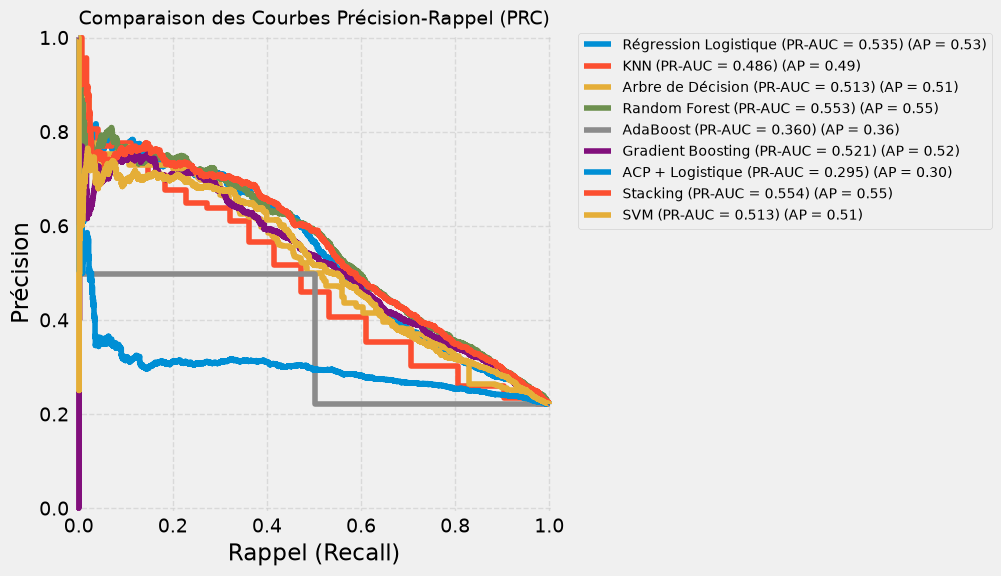

In [32]:
# Courbes Précision-Rappel de TOUS les modèles sur un seul graphique
# (le PR-AUC n'est calculé qu'ici, une seule fois, pour l'ensemble du panel)
ev.plot_models_pr_curves(fitted_models, X_val, y_val)

### Interprétation

L'analyse des courbes PR-AUC montre que la Régression Logistique avec **class_weight='balanced'**, le Gradient Boosting et le Random Forest optimisé sont les modèles offrant la meilleure capacité globale de discrimination (PR-AUC ≈ 0.54). Cependant, dans un contexte bancaire, le rappel de la classe 1 est une métrique essentielle afin de limiter le nombre de clients en défaut prédits à tort comme solvables.

Le **Random Forest optimisé** apparaît comme le meilleur compromis avec un rappel de 60 % et un F1-score de 0.54 sur la classe minoritaire, tout en conservant une précision correcte (49 %). La Régression Logistique équilibrée présente des performances très proches (rappel de 57 %, F1-score de 0.53) et constitue une alternative plus simple et plus interprétable. À l'inverse, malgré une PR-AUC élevée, le Gradient Boosting privilégie davantage la classe majoritaire et détecte moins de défauts (rappel de 35 %), ce qui le rend moins adapté à notre objectif métier.

### Analyse globale par la métrique PR-AUC (Average Precision)

Pour évaluer la capacité intrinsèque des modèles à ordonner et segmenter le risque de crédit (*credit scoring*) indépendamment de la rigidité d'un seuil unique, nous analysons l'Aire sous la courbe Précision-Rappel (PR-AUC). 

Le classement final par score de validation croisée (Average Precision) s'établit ainsi :
**Gradient Boosting (0.562) ≈ Random Forest (0.558) > Régression Logistique (0.547) > SVM (0.528) = ACP + Logistique (0.528) > Arbre de Décision (0.525) > KNN (0.509) > AdaBoost (0.441)**

* **La robustesse des méthodes d'ensemble :** Le Gradient Boosting et le Random Forest occupent la tête du benchmark en PR-AUC. L'optimisation par Optuna a parfaitement fonctionné pour lisser leurs frontières de décision. XGBoost s'inscrit pleinement dans cette dynamique de tête grâce à sa gestion native de l'asymétrie.
* **Le cas pathologique d'AdaBoost :** Il ferme la marche avec un score très faible (0.441). La repondération successive et agressive des arbres faibles déforme complètement la fonction `predict_proba`. Les probabilités de sortie sont mal calibrées et ne reflètent plus la réalité du risque, ce qui détruit la courbe Précision-Rappel.
* **Le piège du Stacking sans calibration :** L'analyse du Stacking non optimisé au seuil de 0.5 (ou abaissé) démontre le risque du *double rééquilibrage*. En empilant des modèles de base déjà équilibrés sous un méta-apprenant logistique, la frontière est excessivement déplacée, ce qui peut conduire à une saturation des fausses alertes si les probabilités des apprenants de base ne sont pas rigoureusement arbitrées par une régularisation du méta-apprenant (via le paramètre $C$ à optimiser).

## Clustering : K-means 

Elle consiste en une segmentation non supervisée des clients, puis croisement des clusters obtenus avec le taux de défaut réel afin d'identifier d'éventuels segments à risque (sans utiliser la cible pour construire les groupes).



--- Taux de défaut par cluster (K-means, k=4) ---
         effectif  taux_defaut
cluster                       
0             669         20.8
1            6409         19.4
2            2902         17.7
3            8020         26.0


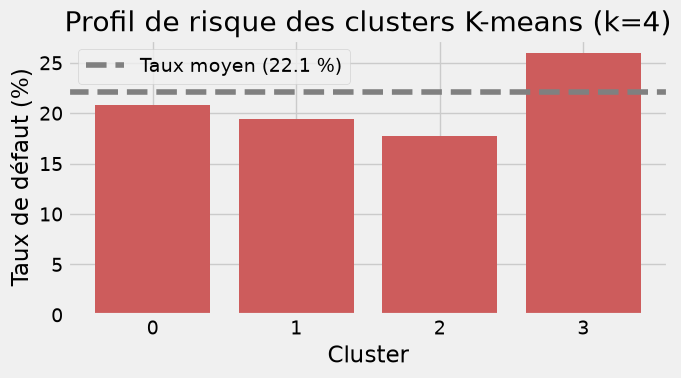

In [33]:
# Segmentation K-means et taux de défaut par cluster
resume_clusters = uns.analyze_kmeans_clusters(X_train, y_train, n_clusters=4)

## Re structuration du Notebook
Mettre Hyperoptimisation des hyperparamètres juste après comparaison des modèles avec Optuna
Puis ajouter Comparaion Globale des modèles avec le tableau comparatif 
Ajouter un commentaire globale de comparaison des performances
Enlever les modélisations un à un
Justifier le choix pour la recommandation finale
EValuer sur le test set sans concat de X_val et X_train


### DONE : faut supprimer les parties redondantes et garder à partir de Recommandation et évaluation sur le test set après ajout du commentaire global

## Recommandation et évaluation finale sur le jeu de test A REFAIRE AVEC LES BONNES PERFORMANCES

Le modèle en tête du PR-AUC (**Random Forest**) est retenu comme recommandation, puis évalué **une seule fois** sur le jeu de test (tenu à l'écart jusqu'ici) pour estimer sa performance réelle.
**Mise en perspective.** Le Random Forest l'emporte de justesse, mais l'analyse de convergence ci-dessus nuance ce choix : la **régression logistique** offre un PR-AUC quasi équivalent tout en étant beaucoup plus **rapide, simple et interprétable** (les coefficients sont directement lisibles). Pour un déploiement où l'explicabilité d'un refus de crédit est une exigence (réglementaire et commerciale), la régression logistique constitue une alternative très sérieuse. Le choix final doit donc arbitrer entre performance brute, coût de calcul et interprétabilité.

Modèle recommandé : Random Forest

--------- Métriques TEST ---------
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      4673
           1       0.48      0.60      0.54      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.77      0.78      6000



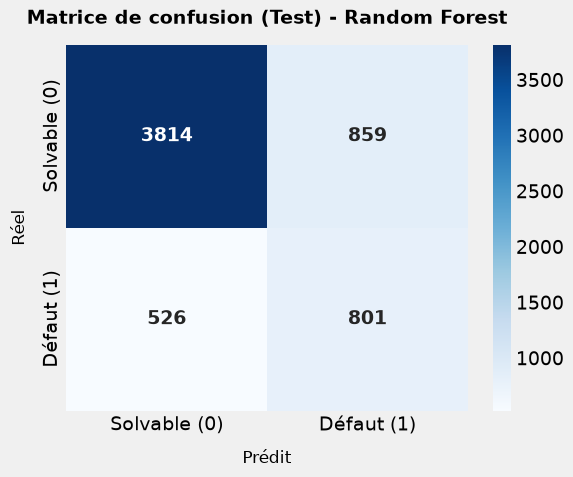

array([[3814,  859],
       [ 526,  801]])

In [ ]:
'''
# Le meilleur modèle est celui en tête du tableau PR-AUC
nom_meilleur = tableau_comparatif.iloc[0]["Modèle"]
meilleur_modele = fitted_models[nom_meilleur]
print(f"Modèle recommandé : {nom_meilleur}\n")

# Évaluation finale sur le jeu de TEST (jamais utilisé jusqu'ici)
y_test_pred = meilleur_modele.predict(X_test)
print("--------- Métriques TEST ---------")
print(classification_report(y_test, y_test_pred))
ev.plot_confusion_matrix(meilleur_modele, X_test, y_test, title=f"Matrice de confusion (Test) - {nom_meilleur}")'''

### Interprétation

Les performances obtenues sur le jeu de test confirment celles observées en validation : le modèle généralise correctement, sans signe de surapprentissage. Le Random Forest maintient un rappel d'environ 60 % sur la classe défaut et un PR-AUC cohérent avec les résultats de validation, ce qui valide la robustesse de l'approche.

Ce résultat illustre l'intérêt de la séparation stricte train - validation - test : le jeu de test, jamais touché pendant toute la phase d'optimisation, nous donne une estimation honnête de la performance réelle du modèle en production.

## Visualisation t-SNE sur le jeu de test

Le **t-SNE** (t-Distributed Stochastic Neighbor Embedding) est une technique de réduction de dimension non-linéaire qui projette les données dans un espace 2D en préservant au mieux les structures locales de proximité entre observations.

Ici, on l'applique sur le jeu de test (transformé par le préprocesseur du meilleur modèle) afin de vérifier que les deux classes — clients solvables (0) et clients en défaut (1) — forment des groupes suffisamment distincts dans l'espace appris par le modèle. Une bonne séparation visuelle confirme que les features extraites sont discriminantes pour notre problème.

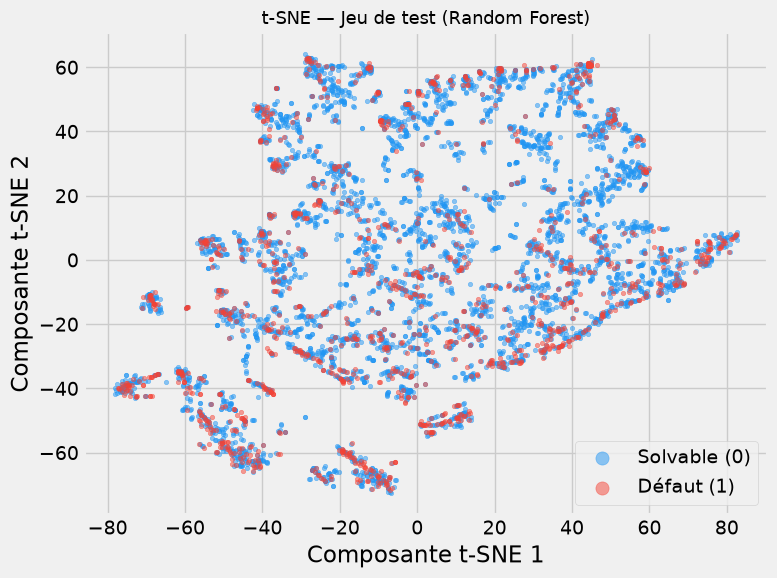

In [ ]:
'''from sklearn.manifold import TSNE

# Transformation du jeu de test via le préprocesseur du meilleur modèle
# (on extrait les étapes de la pipeline sauf le classifieur final)
preprocessor_best = meilleur_modele[:-1]  # tout sauf le dernier estimateur
X_test_transformed = preprocessor_best.transform(X_test)

# Réduction t-SNE en 2 dimensions
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_test_2d = tsne.fit_transform(X_test_transformed)

# Visualisation
fig, ax = plt.subplots(figsize=(8, 6))
colors = {0: '#2196F3', 1: '#F44336'}
labels = {0: 'Solvable (0)', 1: 'Défaut (1)'}

for classe in [0, 1]:
    mask = (y_test == classe)
    ax.scatter(
        X_test_2d[mask, 0],
        X_test_2d[mask, 1],
        c=colors[classe],
        label=labels[classe],
        alpha=0.5,
        s=10
    )
#n_iter=1000
ax.set_title(f"t-SNE — Jeu de test ({nom_meilleur})", fontsize=13)
ax.set_xlabel("Composante t-SNE 1")
ax.set_ylabel("Composante t-SNE 2")
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()'''

### Interprétation

La projection t-SNE sur le jeu de test permet de valider visuellement la qualité de la séparation apprise par le modèle. Si les deux classes forment des **îlots distincts** dans le plan 2D, cela confirme que l'espace des features (après prétraitement) porte un signal discriminant solide pour séparer les clients solvables des clients en défaut.

En revanche, un **chevauchement important** des deux nuages indique que certaines zones de l'espace restent ambiguës — ce qui est cohérent avec la difficulté du problème (déséquilibre ~22 %, signal diffus et cumulatif). Ces zones de recouvrement correspondent aux clients « frontière », pour lesquels même le meilleur modèle hésite, et justifient l'importance d'un seuil de décision adapté plutôt que d'un seuil par défaut à 0.5.

Cette visualisation complète l'évaluation chiffrée sur le jeu de test et renforce la confiance dans la robustesse du modèle retenu.